### SparseDPC Policy Training & Pruning Pipeline

This notebook outlines the SparseDPC workflow for training sparse, interpretable control policies. The process begins with **training a SINDy model for system identification**, capturing the dynamics from data using symbolic regression.

Key steps:

- **System ID:** Fit a SINDy model to identify system dynamics using a polynomial or Fourier library.
- **Policy Modeling:** Use the identified dynamics as the base for constructing symbolic policy models.
- **Training:** Train policies via differentiable optimization using Neuromancer's `SparseTrainer`.
- **Pruning:** Iteratively prune insignificant terms based on learned coefficients to simplify expressions.
- **Logging:** Track metrics and active terms with a custom logger for interpretability and reproducibility.

The result is a sparse, symbolic policy that is data-driven and control-ready.


In [7]:
# IF you are using Colab:
#!pip install git+https://github.com/Alirezad126/SparseDPC.git@new

### 📦 Imports and Environment Setup


In [8]:
import torch.nn as nn
import os
import copy
import torch
import numpy as np
import wandb
from datetime import datetime
import matplotlib.pyplot as plt
import copy
import os, json, numpy as np, torch
from pathlib import Path

# Neuromancer imports: modeling, loss, logging, system dynamics
from neuromancer.loggers import BasicLogger
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import ode, integrators
from neuromancer.plot import pltCL, pltPhase

# SparseDPC-specific modules: libraries, data, training, utils
from SparseDPC.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.data.getdata import get_data, get_policy_data
from SparseDPC.trainer.trainer import SparseTrainer
from SparseDPC.utils.integrator import OneElementEulerIntegrator, FullStateEulerIntegrator
from SparseDPC.utils.utils import map_to_new_fx, save_model_with_timestamp
from SparseDPC.utils.loggers import CustomLogger
from SparseDPC.trainer.problem import SparsePolicyBuilder, SparseDynamicsBuilder
from SparseDPC.sindy.fx_library import fx_policy_library
from SparseDPC.utils.utils       import map_to_new_fx, save_model_with_timestamp

# Set random seed for reproducibility
torch.manual_seed(0)

# Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


## ⚙️ Training System ID with SINDy


### ⚙️ Define Ground Truth System and Problem Parameters



In [9]:
# ground truth system model
gt_model = psl.nonautonomous.VanDerPolControl()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = -5.
umax = 5.
xmin = -5.
xmax = 5.



### 🧠 Generate Candidate Sparse Dynamics Models

This cell creates a list of candidate sparse dynamic models for each state dimension using `fx_library`, and prints them for inspection. Each model is configured with the same number of states, inputs, and device.


In [37]:
fx_models = [fx_library(i, nx=nx, nu=nu, seed=0, device=device,
                           max_degree=4, add_sqrt=False, add_u_prod=True) for i in range(nx)]
for fx in fx_models:
    print(fx)

dx0/dt = -0.001*x0 + 0.054*x1 + -0.082*x0^2 + -0.074*x0*x1 + -0.039*x1^2 + 0.027*x0^3 + -0.002*x0^2*x1 + 0.079*x0*x1^2 + -0.009*x1^3 + 0.026*x0^4 + -0.030*x0^3*x1 + -0.020*x0^2*x1^2 + -0.096*x0*x1^3 + -0.066*x1^4 + -0.041*u_0 + 0.004*x0*u_0 + 0.040*x1*u_0

dx1/dt = -0.001*x1 + 0.054*x0 + -0.082*x0^2 + -0.074*x0*x1 + -0.039*x1^2 + 0.027*x0^3 + -0.002*x0^2*x1 + 0.079*x0*x1^2 + -0.009*x1^3 + 0.026*x0^4 + -0.030*x0^3*x1 + -0.020*x0^2*x1^2 + -0.096*x0*x1^3 + -0.066*x1^4 + -0.041*u_0 + 0.004*x0*u_0 + 0.040*x1*u_0



### 🔁 Train SINDy for System ID

Trains a sparse model for each state using one-step loss.
High `epochs` and `prune_every` allow convergence before pruning.
- `threshold`: sparsity cutoff for pruning small weights
- `threshold_mult`: increasing the threshold after prunning, as coefficient of the remaining terms will grow after prunning other unimportant terms


In [38]:
nsim = 2000   # number of simulation steps in the dataset
nsteps = 2  # number of prediction horizon steps in the loss function
bs = 100     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

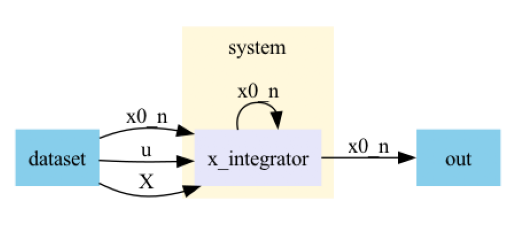

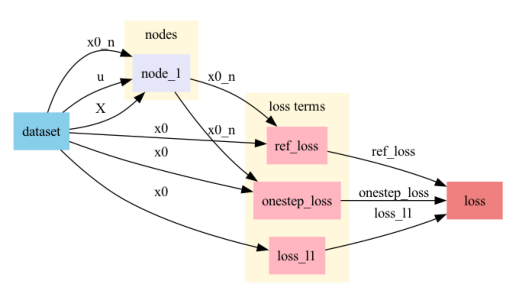

None
epoch: 0	train_loss: 0.00069	dev_loss: 0.00069	eltime:  0.46826
epoch: 500	train_loss: 0.00000	dev_loss: 0.00000	eltime:  17.47023

--- Model 0 BEFORE pruning ---
dx0/dt = -0.038*x0 + 1.047*x1 + -0.001*x0^2 + 0.007*x0*x1 + -0.002*x1^2 + -0.000*x0^3 + -0.039*x0^2*x1 + -0.007*x0*x1^2 + 0.001*x1^3 + 0.000*x0^4 + -0.002*x0^3*x1 + 0.001*x0^2*x1^2 + -0.001*x0*x1^3 + 0.000*x1^4 + 0.038*u_0 + 0.002*x0*u_0 + 0.001*x1*u_0

   Threshold=1.10e-01, Active=1, Pruned: ['x0', 'x0^2', 'x0*x1', 'x1^2', 'x0^3', 'x0^2*x1', 'x0*x1^2', 'x1^3', 'x0^4', 'x0^3*x1', 'x0^2*x1^2', 'x0*x1^3', 'x1^4', 'u_0', 'x0*u_0', 'x1*u_0']
⇒ Active set changed. Adding small noise to retained coefficients.

---------- Model 0 AFTER pruning  ----------
dx0/dt = 1.092*x1

epoch: 1000	train_loss: 0.00001	dev_loss: 0.00013	eltime:  34.44622
epoch: 1500	train_loss: 0.00020	dev_loss: 0.00011	eltime:  48.09608

--- Model 0 BEFORE pruning ---
dx0/dt = 0.993*x1

   Threshold=1.16e-01, Active=1, Pruned: []
⇒ No change in active term

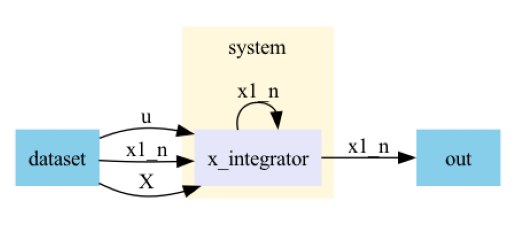

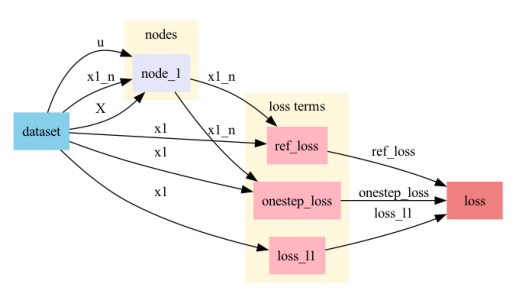

None
epoch: 0	train_loss: 0.21565	dev_loss: 0.10863	eltime:  0.45156
epoch: 500	train_loss: 0.00041	dev_loss: 0.00018	eltime:  16.61059

--- Model 0 BEFORE pruning ---
dx1/dt = 0.930*x1 + -0.875*x0 + 0.001*x0^2 + -0.013*x0*x1 + -0.013*x1^2 + -0.001*x0^3 + -0.891*x0^2*x1 + -0.101*x0*x1^2 + -0.004*x1^3 + 0.001*x0^4 + 0.014*x0^3*x1 + 0.036*x0^2*x1^2 + -0.012*x0*x1^3 + 0.002*x1^4 + 0.897*u_0 + -0.008*x0*u_0 + -0.009*x1*u_0

   Threshold=1.10e-01, Active=4, Pruned: ['x0^2', 'x0*x1', 'x1^2', 'x0^3', 'x0*x1^2', 'x1^3', 'x0^4', 'x0^3*x1', 'x0^2*x1^2', 'x0*x1^3', 'x1^4', 'x0*u_0', 'x1*u_0']
⇒ Active set changed. Adding small noise to retained coefficients.

---------- Model 0 AFTER pruning  ----------
dx1/dt = 0.919*x1 + -0.882*x0 + -0.883*x0^2*x1 + 0.923*u_0

epoch: 1000	train_loss: 0.00015	dev_loss: 0.00206	eltime:  34.01313
epoch: 1500	train_loss: 0.00046	dev_loss: 0.00052	eltime:  47.54699

--- Model 0 BEFORE pruning ---
dx1/dt = 0.810*x1 + -0.989*x0 + -0.962*x0^2*x1 + 0.989*u_0

   Thresho

In [40]:
for i in range(nx):

    nsim = 2000   # number of simulation steps in the dataset
    nsteps = 2  # number of prediction horizon steps in the loss function
    bs = 100     # minibatching batch size
    train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

    integrator_x = OneElementEulerIntegrator(fx_models[i], h=ts)
    integrator_node_x = Node(integrator_x, ['X', f'x{i}_n', 'u'], [f'x{i}_n'], name="x_integrator")
    dynamics_model_x = System([integrator_node_x])

    dynamics_model_x.show()

    x = variable(f"x{i}")
    x_hat = variable(f'x{i}_n')[:, :-1, :]

    # Loss
    onestep_loss_x = 1.0 * ((x_hat[:, 1, :] == x[:, 1, :])^ 2)
    onestep_loss_x.name = "onestep_loss"

    reference_loss_x = 3. *((x_hat == x) ^ 2)
    reference_loss_x.name = "ref_loss"

    # Sparsity constraint
    l1_x = variable([x], lambda x: torch.norm(list(fx_models[i].parameters())[0], p=1))
    loss_l1_x = 1e-9 * (l1_x == 0)
    loss_l1_x.name = "loss_l1"

    objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
    loss_x = PenaltyLoss(objectives_x, [])
    problem_x = Problem([dynamics_model_x], loss_x)
    problem_x.show()

    lr = 1e-3
    optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

    logger = BasicLogger(args=None, savedir='test', verbosity=500,
                    stdout=['dev_loss', 'train_loss'])
    epochs=3000

    trainer_x = SparseTrainer(
        problem      = problem_x,
        fx_models  = [fx_models[i]],      # list of SINDy models
        lr           = 1e-3,
        train_data=None,
        test_data=None,
        optimizers=[optimizer_x],
        epochs=epochs,
        train_metric='train_loss',
        eval_metric='dev_loss',
        logger=logger,
        device=device,
        threshold=0.11,
        prune_every=1000,
        warmup=300,
        patience=50,
        threshold_mult=1.05,
        )
    for _ in range(4):

        train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)
        trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
        trainer_x.problem = problem_x  # Keep the problem consistent

        # Train control policy
        best_model = trainer_x.train()


        trainer_x.model.load_state_dict(best_model)

        # Update step size
        nsteps *= 2
        dynamics_model_x.nsteps = nsteps
        trainer_x.lr *= 0.8




In [41]:
for fx in fx_models:
    print(fx)

dx0/dt = 1.001*x1

dx1/dt = 0.884*x1 + -0.984*x0 + -0.991*x0^2*x1 + 0.986*u_0



In [42]:
integrator_x = FullStateEulerIntegrator(fx_models, ts)          # custom step
x_integrator_node= Node(integrator_x,['xn', 'u'], ['xn'], name=f"x_integrator")


sindy_system = System(
    [x_integrator_node],
    nsteps=nsteps
)

### 📈 Evaluate SINDy Model

Simulates and plots predicted vs. true trajectories using the learned full-state model.


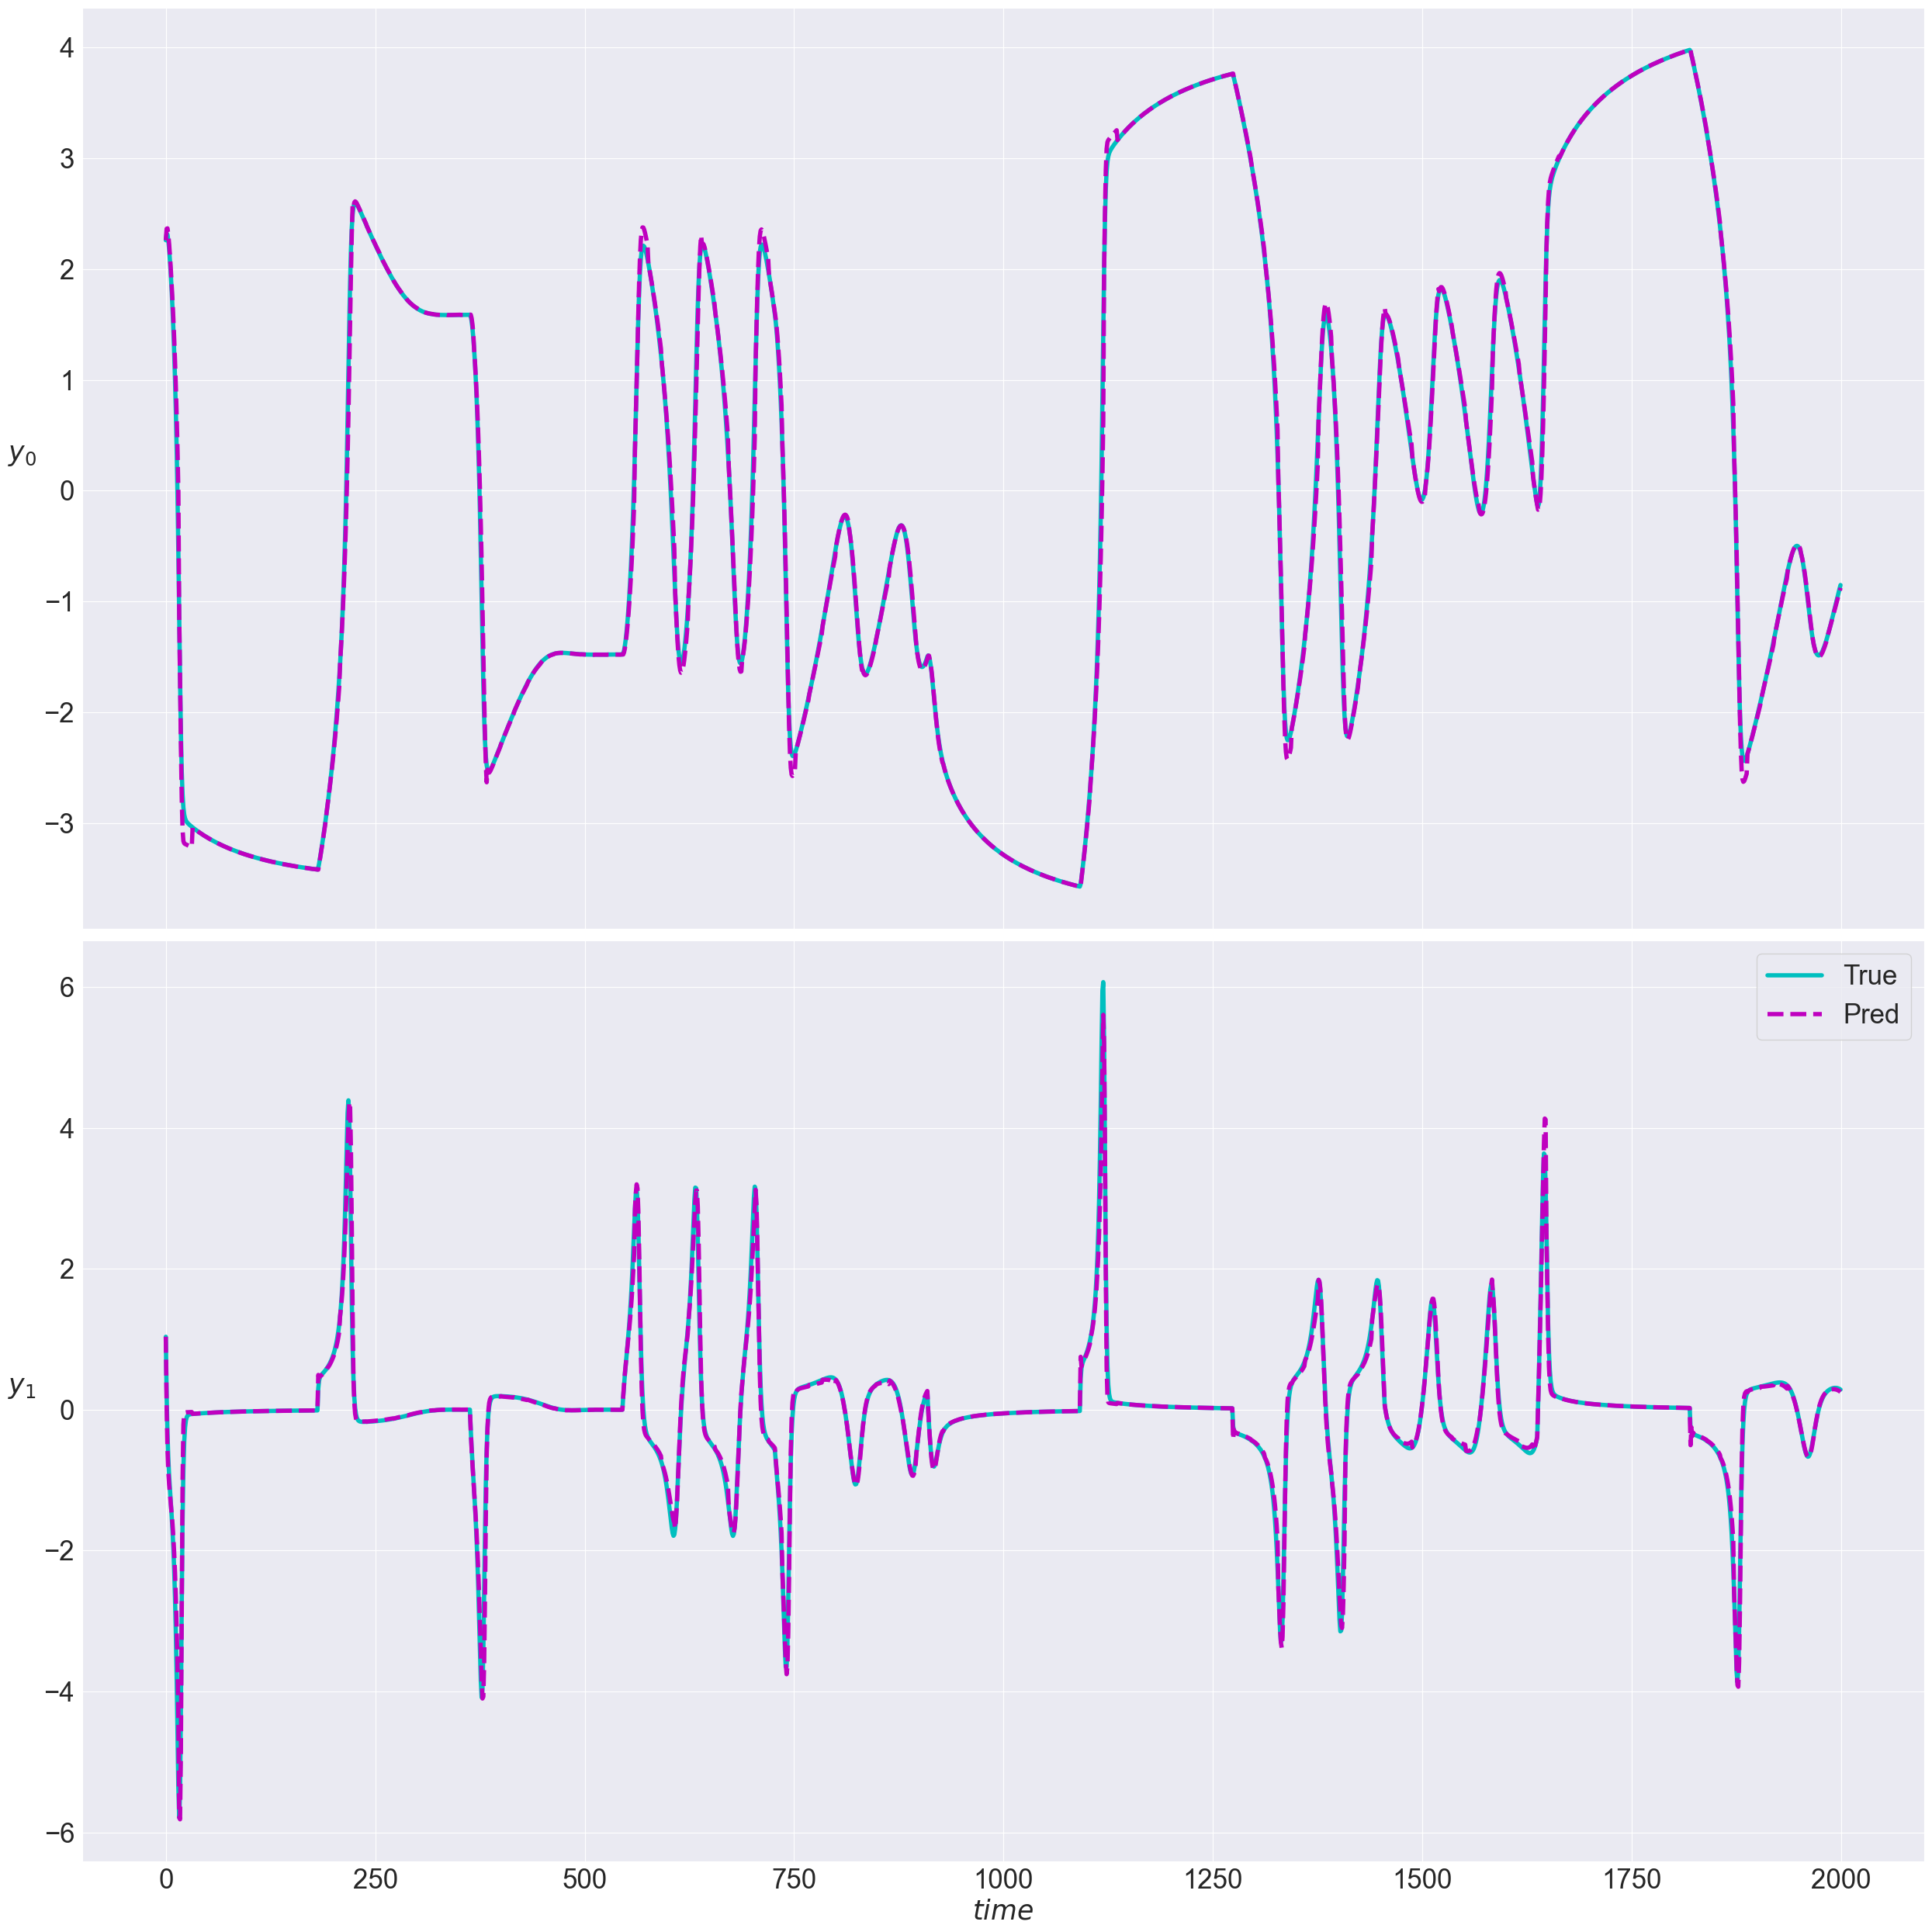

In [43]:
import matplotlib.pyplot as plt

sindy_system.nsteps = test_data['X'].shape[1]
test_output = sindy_system(test_data)

pred_traj = test_output['xn'][:, :-1, :]
true_traj = test_data['X']
pred_traj = pred_traj.detach().numpy().reshape(-1, nx)
true_traj = true_traj.detach().numpy().reshape(-1, nx)
pred_traj, true_traj = pred_traj.transpose(1, 0), true_traj.transpose(1, 0)

figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]
for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    if nx > 1:
        axe = ax[row]
    else:
        axe = ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)
axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()

In [45]:

# ---------------- user-supplied objects & constants ------------------------ #
base_dir       = "results/tests/dynamics"
# --------------------------------------------------------------------------- #

run_id  = 1
while Path(base_dir, f"run_{run_id}").exists():
    run_id += 1
run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)

models_dir = run_dir / "saved_models"; models_dir.mkdir()

for i in range(nx):
    # ---- prepare *mapped* model to full library & save .pt ----------
    full_lib   = fx_library(i, nx=nx, nu=nu, seed=0, device=device,
                           max_degree=4, add_sqrt=False, add_u_prod=True)

    mapped_pol = map_to_new_fx(fx_models[i], full_lib)
    save_model_with_timestamp(mapped_pol,
                              f"trained_dynamics_x{i}",
                              models_dir)

    # ---- JSON log of the *trained (pruned) dynamics* ------------------
    orig_fx = fx_models[i]
    coef   = orig_fx.coef.detach().cpu().numpy().flatten().tolist()
    fnames = orig_fx.library.function_names
    expr   = str(orig_fx)

    log_entry = {
        "function_names": fnames,
        "coef":           coef,
        "expr":           expr
    }
    with open(run_dir / f"x{i}_log.json", "w") as f:
        json.dump(log_entry, f, indent=2)

print(f"✓  results saved under  {run_dir.as_posix()}")


✅ Model saved to results/tests/dynamics/run_1/saved_models/trained_dynamics_x0_20250810_153554.pth
✅ Model saved to results/tests/dynamics/run_1/saved_models/trained_dynamics_x1_20250810_153554.pth
✓  results saved under  results/tests/dynamics/run_1


## ⚙️ Training the Sparse Dictionary Policy


###  Load Policy Data

Loads the trainig data for control problem


In [16]:
# import importlib
# import SparseDPC.data.getdata
# importlib.reload(SparseDPC.data.getdata)
# from SparseDPC.data.getdata import get_policy_data


nsteps = 50  # prediction horizon
n_samples = 1500   # number of sampled scenarios
train_loader, dev_loader = get_policy_data(nsteps=nsteps,
                                           n_samples=n_samples,
                                           nx=nx,
                                           xmin=xmin,
                                           xmax=xmax,
                                           zero_refs=True,
                                           same_ref_for_all_states=True,
                                           device=device,
                                           batch_size=200,
                                           seed=5
                                           )

###  Run Policy Training Grid

Trains and saves SINDy policies across multiple `l1_coef` and `threshold` configs with logging and pruning.


In [17]:
# import json
#
# # === Setup ===
# nsteps = 50
# session_id = datetime.now().strftime("%Y%m%d_%H%M%S")
# session_folder = f"results/session_{session_id}"
# os.makedirs(session_folder, exist_ok=True)
#
# # === Base Configuration ===
# base_config = {
#     'reg_coef': 100.0,
#     'l1_coef': 1e-2,
#     'const_coef': 10.0,
#     'lr': 5e-3,
#     'epochs': 2499,
#     'threshold': 0.1,
#     'prune_every': 250,
#     'threshold_mult': 1.1,
# }
# policies_seed = 5
# l1_coef_list = [1e-2, 5e-3, 1e-3]
# thresholds = [0.3, 0.2, 0.1, 0.05]
#
# # === Run All Configurations ===
# run_id = 0
# for l1_coef in l1_coef_list:
#     for threshold in thresholds:
#         run_id += 1
#         pol_configs = copy.deepcopy(base_config)
#         pol_configs['threshold'] = threshold
#         pol_configs['run_id'] = run_id
#
#         run_name = f"VanDerPol_run{run_id}_l1coef{l1_coef}_th{threshold}"
#         save_dir = os.path.join(session_folder, run_name)
#         os.makedirs(save_dir, exist_ok=True)
#
#         wandb.init(
#             project="sindy-VanDerPol-multi-config",
#             name=run_name,
#             config=pol_configs,
#             dir=save_dir,
#             reinit=True
#         )
#
#         # === Policy Setup ===
#         policies = [
#             fx_policy_library(nx=nx, nref=0, policy_name=f"u_{i}", seed=policies_seed, device=device) for i in range(nu)
#         ]
#
#         policy_node = Node(
#             lambda xn, r: torch.cat([torch.clamp(fp(xn, r), umin, umax) for fp in policies], dim=-1),
#             ['xn', 'r'], ['u'], name="policy_combined"
#         )
#
#         integrator_x = FullStateEulerIntegrator(fx_models, ts)
#         x_integrator_node = Node(integrator_x, ['xn', 'u'], ['xn'], name="x_integrator")
#         sindy_system = System([policy_node, x_integrator_node], nsteps=nsteps)
#
#         x = variable('xn')
#         ref = variable('r')
#         regulation_loss = pol_configs['reg_coef'] * ((x == ref) ^ 2)
#         regulation_loss.name = "state_loss"
#
#         loss_l1_policies = []
#         for idx, fp in enumerate(policies):
#             l1_raw = variable([x], lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1), display_name=f"l1_policy{idx}")
#             l1_pen = l1_coef * (l1_raw == 0)
#             l1_pen.name = f"loss_l1_policy_{idx}"
#             loss_l1_policies.append(l1_pen)
#
#         c = pol_configs['const_coef']
#         state_lower = c * (x > xmin); state_lower.name = "x_min"
#         state_upper = c * (x < xmax); state_upper.name = "x_max"
#         term_lower = c * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
#         term_upper = c * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"
#
#         objectives = [regulation_loss, *loss_l1_policies]
#         constraints = [state_lower, state_upper, term_lower, term_upper]
#         loss = PenaltyLoss(objectives, constraints)
#         problem = Problem([sindy_system], loss)
#
#         logger = CustomLogger(
#             args=None,
#             save_dir=save_dir,
#             verbosity=10,
#             stdout=['train_loss', 'dev_loss'],
#             fx_policies=policies,
#             pol_configs=pol_configs
#         )
#
#         trainer_policy = SparseTrainer(
#             problem=problem,
#             fx_models=policies,
#             lr=pol_configs['lr'],
#             train_data=train_loader,
#             dev_data=dev_loader,
#             optimizers=[torch.optim.AdamW(fp.parameters(), lr=pol_configs['lr']) for fp in policies],
#             epochs=pol_configs['epochs'],
#             train_metric='train_loss',
#             eval_metric='dev_loss',
#             logger=logger,
#             device=device,
#             threshold=pol_configs['threshold'],
#             prune_every=pol_configs['prune_every'],
#             threshold_mult=pol_configs['threshold_mult']
#         )
#
#         best_state = trainer_policy.train()
#         # === Save final coefficients
#         for i, fp in enumerate(policies):
#             coef = fp.coef.detach().cpu().numpy()
#             np.savetxt(f"{save_dir}/policy{i}_final.csv", coef, delimiter=",")
#             wandb.log({f"final_active_terms_policy_{i}": int(np.count_nonzero(coef))})
#
#         # === Save mapped models
#         models_dir = os.path.join(save_dir, "saved_models")
#         os.makedirs(models_dir, exist_ok=True)
#
#         # Create corresponding master policies and save the mapped models
#         for i in range(nu):
#             policy_name = f"u_{i}"
#
#             # Create a base fx policy (untrained) to map to full library
#             policy_base = fx_policy_library(
#                 nx=nx, nref=1, policy_name=policy_name, seed=policies_seed, device=device
#             )
#
#             # Map trained policy to full library structure
#             policy_mapped = map_to_new_fx(policies[i], policy_base)
#
#             # Save the mapped model
#             save_model_with_timestamp(policy_mapped, f"trained_policy_{i}", models_dir)
#
#         with open(os.path.join(save_dir, "run_config.json"), "w") as f:
#             json.dump(pol_configs, f, indent=4)
#
#         wandb.finish()
#
# # === Save session metadata ===
# with open(os.path.join(session_folder, "session_config.txt"), "w") as f:
#     f.write(f"Session ID: {session_id}\n")
#     f.write(f"Started at: {datetime.now()}\n")
#     f.write(f"Total runs: {run_id}\n")
#     f.write(f"L1 Coef List: {l1_coef_list}\n")
#     f.write(f"Thresholds: {thresholds}\n")


In [18]:
# import os
# import copy
# import torch
# import numpy as np
# import wandb
# from datetime import datetime
#
# # Create a unique session folder based on timestamp (or manually set one)
# session_id = datetime.now().strftime("%Y%m%d_%H%M%S")
# session_folder = f"results/session_{session_id}"
# os.makedirs(session_folder, exist_ok=True)
#
# # Base config
# base_config = {
#     'reg_coef': 100.0,
#     'l1_coef': 1e-2,
#     'const_coef': 20.0,
#     'lr': 1e-2,
#     'epochs': 1500,
#     'threshold': 0.1,
#     'prune_every': 150,
#     'threshold_mult': 1.1,
# }
# policies_seed=5
# # All variations
# l1_coef_list = [5e-2, 1e-2, 5e-3, 1e-3]
# thresholds = [0.3, 0.2, 0.1, 0.05]
#
# run_id = 0
# for l1_coef in l1_coef_list:
#     for threshold in thresholds:
#         run_id += 1
#         pol_configs = copy.deepcopy(base_config)
#         pol_configs['threshold'] = threshold
#         pol_configs['run_id'] = run_id
#
#         run_name = f"VanDerPol_run{run_id}_l1coef{l1_coef}_th{threshold}"
#         save_dir = os.path.join(session_folder, run_name)
#         os.makedirs(save_dir, exist_ok=True)
#
#         # Initialize W&B for this run
#         wandb.init(
#             project="sindy-VanDerPol-multi-config",
#             name=run_name,
#             config=pol_configs,
#             dir=save_dir,
#             reinit=True
#         )
#
#         fx_policies = [fx_policy_library(nx=2, nref=1, policy_name= "u",
#                                          seed=policies_seed, device=device)]
#
#         policy_node = Node(
#             lambda xn, r: torch.cat([torch.clamp(fp(xn, r), umin, umax) for fp in fx_policies], dim=-1),
#             ['xn', 'r'], ['u'], name="policy_combined"
#         )
#
#         integrator_x = FullStateEulerIntegrator(fx_models, ts)
#         x_integrator_node = Node(integrator_x, ['xn', 'u'], ['xn'], name="x_integrator")
#         sindy_system = System([policy_node, x_integrator_node], nsteps=nsteps)
#
#         x = variable('xn')
#         ref = variable('r')
#         regulation_loss = pol_configs['reg_coef'] * ((x == ref) ^ 2)
#         regulation_loss.name = "state_loss"
#
#         loss_l1_policies = []
#         for idx, fp in enumerate(fx_policies):
#             l1_raw = variable([x], lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1), display_name=f"l1_policy{idx}")
#             l1_pen = l1_coef * (l1_raw == 0)
#             l1_pen.name = f"loss_l1_policy_{idx}"
#             loss_l1_policies.append(l1_pen)
#
#         c = pol_configs['const_coef']
#         state_lower = c * (x > xmin); state_lower.name = "x_min"
#         state_upper = c * (x < xmax); state_upper.name = "x_max"
#         term_lower = c * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
#         term_upper = c * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"
#
#         objectives = [regulation_loss, *loss_l1_policies]
#         constraints = [state_lower, state_upper, term_lower, term_upper]
#         loss = PenaltyLoss(objectives, constraints)
#         problem = Problem([sindy_system], loss)
#
#         logger = CustomLogger(
#             args=None,
#             save_dir=save_dir,
#             verbosity=10,
#             stdout=['train_loss', 'dev_loss'],
#             fx_policies=fx_policies,
#             pol_configs=pol_configs
#         )
#
#         trainer_policy = SparseTrainer(
#             problem=problem,
#             fx_models=fx_policies,
#             lr=pol_configs['lr'],
#             train_data=train_loader,
#             dev_data=dev_loader,
#             optimizers=[torch.optim.AdamW(fp.parameters(), lr=pol_configs['lr']) for fp in fx_policies],
#             epochs=pol_configs['epochs'],
#             train_metric='train_loss',
#             eval_metric='dev_loss',
#             logger=logger,
#             device=device,
#             threshold=pol_configs['threshold'],
#             prune_every=pol_configs['prune_every'],
#             threshold_mult=pol_configs['threshold_mult']
#         )
#
#         best_state = trainer_policy.train()
#         trainer_policy.model.load_state_dict(best_state)
#
#         for i, fp in enumerate(fx_policies):
#             coef = fp.coef.detach().cpu().numpy()
#             np.savetxt(f"{save_dir}/policy{i}_final.csv", coef, delimiter=",")
#             wandb.log({f"final_active_terms_policy_{i}": int(np.count_nonzero(coef))})
#
#         wandb.finish()
#
#
#
# # ========================
# # 5. Save session metadata
# # ========================
# with open(os.path.join(session_folder, "session_config.txt"), "w") as f:
#     f.write(f"Session ID: {session_id}\n")
#     f.write(f"Started at: {datetime.now()}\n")
#     f.write(f"Total runs: {run_id}\n")
#     f.write(f"L1 Coef List: {l1_coef_list}\n")
#     f.write(f"Thresholds: {thresholds}\n")


###  Train Combined Policy

Trains policy models jointly using a SINDy model with specific configuration


In [49]:
# import importlib
# import SparseDPC.data.getdata
# importlib.reload(SparseDPC.data.getdata)
# from SparseDPC.data.getdata import get_policy_data


nsteps = 50  # prediction horizon
n_samples = 2000   # number of sampled scenarios
policies_seed = 5
train_loader, dev_loader = get_policy_data(nsteps=nsteps,
                                           n_samples=n_samples,
                                           nx=nx,
                                           xmin=-4,
                                           xmax=4,
                                           zero_refs=True,
                                           same_ref_for_all_states=True,
                                           device=device,
                                           batch_size=200,
                                           seed=22
                                           )

In [20]:
import importlib
import SparseDPC.trainer.problem
import SparseDPC.sindy.sindy
import SparseDPC.sindy.fx_library
importlib.reload(SparseDPC.trainer.problem)
importlib.reload(SparseDPC.sindy.sindy)
importlib.reload(SparseDPC.sindy.fx_library)
from SparseDPC.trainer.problem import SparsePolicyBuilder
from SparseDPC.sindy.sindy import SINDy
from SparseDPC.sindy.fx_library import fx_policy_library


None


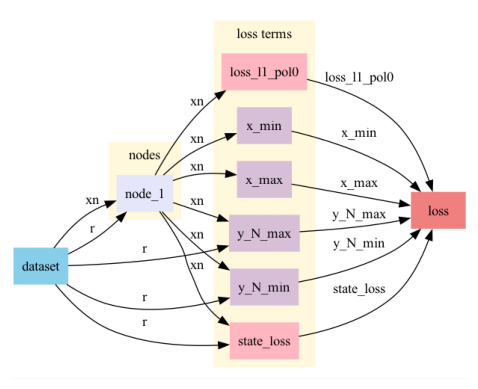

None


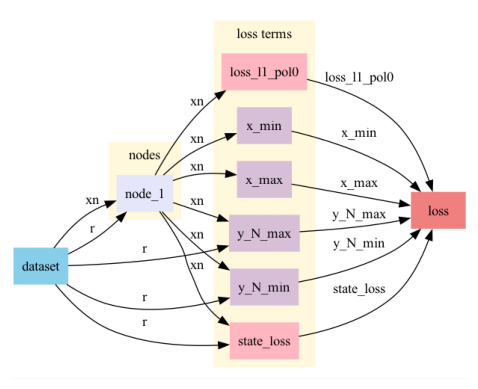

In [21]:
pol_configs = {
    "reg_coef": 20.0,
    "l1_coef": 0.008,
    "const_coef": 20.0,
    "lr": 0.005,
    "epochs": 3999,
    "threshold": 0.25,
    "prune_every": 400,
    "threshold_mult": 1.17,
    "prune_noise": 0.02
}


builder_SD_SINDy = SparsePolicyBuilder(
    fx_models     = fx_models,
    is_sindy      = True,
    gt_model      = None,
    nx            = nx,
    nref          = 0,
    nu            = nu,
    ts            = ts,
    nsteps        = nsteps,
    train_loader  = train_loader,
    dev_loader    = dev_loader,
    bounds        = dict(
                        xmin=xmin,
                        xmax=xmax,
                        umin=umin,
                        umax=umax
                    ),
    config        = pol_configs,
    seed          = policies_seed,
    device        = device,
    logger        = BasicLogger(args=None, savedir='runs', verbosity=20,
                                stdout=['dev_loss', 'train_loss'])
)

# ODE model with no-plant model mismatch
van_der_pol = ode.VanDerPolControl()                   # ODE system equations implemented in PyTorch
# integrate continuous time ODE
gt_integrator = integrators.Euler(van_der_pol, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

builder_SD_WB = SparsePolicyBuilder(
    fx_models     = fx_models,
    is_sindy      = False,
    gt_model      = van_der_pol,
    nx            = nx,
    nref          = 0,
    nu            = nu,
    ts            = ts,
    nsteps        = nsteps,
    train_loader  = train_loader,
    dev_loader    = dev_loader,
    bounds        = dict(
                        xmin=xmin,
                        xmax=xmax,
                        umin=umin,
                        umax=umax
                    ),
    config        = pol_configs,
    seed          = policies_seed,
    device        = device,
    logger        = BasicLogger(args=None, savedir='runs', verbosity=20,
                                stdout=['dev_loss', 'train_loss'])
)

In [22]:
builder_SD_SINDy.train()

epoch: 0	train_loss: 77.03244	dev_loss: 75.39370	eltime:  1.69545
epoch: 20	train_loss: 28.75764	dev_loss: 27.26348	eltime:  18.99223
epoch: 40	train_loss: 23.09769	dev_loss: 21.84876	eltime:  36.08224
epoch: 60	train_loss: 21.08796	dev_loss: 19.86479	eltime:  53.33930
epoch: 80	train_loss: 20.38197	dev_loss: 19.15940	eltime:  70.36988
epoch: 100	train_loss: 20.03605	dev_loss: 18.81641	eltime:  87.62096
epoch: 120	train_loss: 19.84328	dev_loss: 18.62953	eltime:  104.76200
epoch: 140	train_loss: 19.72563	dev_loss: 18.51559	eltime:  121.98125
epoch: 160	train_loss: 19.64750	dev_loss: 18.43880	eltime:  139.02378
epoch: 180	train_loss: 19.59294	dev_loss: 18.38398	eltime:  156.18026
epoch: 200	train_loss: 19.55053	dev_loss: 18.34128	eltime:  173.24018
epoch: 220	train_loss: 19.51695	dev_loss: 18.30763	eltime:  190.42120
epoch: 240	train_loss: 19.49077	dev_loss: 18.28062	eltime:  207.48655
epoch: 260	train_loss: 19.46886	dev_loss: 18.25817	eltime:  224.68230
epoch: 280	train_loss: 19.45027	d

{}

In [23]:
builder_SD_WB.train()

epoch: 0	train_loss: 79.92097	dev_loss: 78.49524	eltime:  2202.56879
epoch: 20	train_loss: 29.77437	dev_loss: 28.24066	eltime:  2217.69277
epoch: 40	train_loss: 23.69924	dev_loss: 22.42846	eltime:  2232.66132
epoch: 60	train_loss: 21.52537	dev_loss: 20.28713	eltime:  2247.80774
epoch: 80	train_loss: 20.74232	dev_loss: 19.50848	eltime:  2262.88303
epoch: 100	train_loss: 20.36018	dev_loss: 19.13030	eltime:  2278.61495
epoch: 120	train_loss: 20.14012	dev_loss: 18.91914	eltime:  2293.77310
epoch: 140	train_loss: 20.00850	dev_loss: 18.79306	eltime:  2308.91113
epoch: 160	train_loss: 19.92189	dev_loss: 18.70925	eltime:  2324.07015
epoch: 180	train_loss: 19.86240	dev_loss: 18.65041	eltime:  2339.25795
epoch: 200	train_loss: 19.81688	dev_loss: 18.60400	eltime:  2354.24640
epoch: 220	train_loss: 19.78103	dev_loss: 18.56788	eltime:  2369.39923
epoch: 240	train_loss: 19.75326	dev_loss: 18.53959	eltime:  2384.37398
epoch: 260	train_loss: 19.73000	dev_loss: 18.51551	eltime:  2399.61580
epoch: 280	t

{'nodes.0.nodes.1.callable.block.mu': tensor([1.])}

In [24]:
# --------------------------------------------------------------------------- #
# INLINE SNAPSHOT (mapped .pt + raw-policy JSON)
# --------------------------------------------------------------------------- #
import os, json, numpy as np, torch
from pathlib import Path
from SparseDPC.sindy.fx_library import fx_policy_library
from SparseDPC.utils.utils       import map_to_new_fx, save_model_with_timestamp

# ---------------- user-supplied objects & constants ------------------------ #
builders       = {"WB": builder_SD_WB, "SINDy": builder_SD_SINDy}   # tag → builder
base_dir       = "results/tests/sparse"
# --------------------------------------------------------------------------- #

# 1. auto-increment parent run directory
run_id  = 1
while Path(base_dir, f"run_{run_id}").exists():
    run_id += 1
run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)
(Path(run_dir, "run_config.json")
 .write_text(json.dumps(pol_configs, indent=4)))

# 2. iterate over builders
for tag, bld in builders.items():
    tag_dir    = run_dir / tag;          tag_dir.mkdir()
    models_dir = tag_dir / "saved_models"; models_dir.mkdir()

    for i in range(nu):
        # ---- prepare *mapped* model to full library & save .pt ----------
        full_lib   = fx_policy_library(nx=nx, nref=1,
                                       policy_name=f"u_{i}",
                                       seed=policies_seed,
                                       device=bld.device)
        mapped_pol = map_to_new_fx(bld.policies[i], full_lib)
        save_model_with_timestamp(mapped_pol,
                                  f"trained_policy_{i}",
                                  models_dir)

        # ---- JSON log of the *trained (pruned) policy* ------------------
        orig_pol = bld.policies[i]
        coef   = orig_pol.coef.detach().cpu().numpy().flatten().tolist()
        fnames = orig_pol.library.function_names
        expr   = str(orig_pol)

        log_entry = {
            "function_names": fnames,
            "coef":           coef,
            "active_terms":   int(np.count_nonzero(coef)),
            "expr":           expr
        }
        with open(tag_dir / f"policy{i}_log.json", "w") as f:
            json.dump(log_entry, f, indent=2)

print(f"✓  results saved under  {run_dir.as_posix()}")


✅ Model saved to results/tests/sparse/run_3/WB/saved_models/trained_policy_0_20250810_084929.pth
✅ Model saved to results/tests/sparse/run_3/SINDy/saved_models/trained_policy_0_20250810_084929.pth
✓  results saved under  results/tests/sparse/run_3


In [25]:
# # white-box
# policy_node = Node(
#     lambda xn, r: torch.cat(
#         [torch.clamp(fp(xn, r), umin, umax).to(torch.device('cpu'))  # capture fp by value
#          for fp in fx_policies],
#         dim=-1),
#     ['xn', 'r'], ['u'],
#     name="policy_combined"
# )
#
#
# # ODE model with no-plant model mismatch
# van_der_pol = ode.VanDerPolControl()                   # ODE system equations implemented in PyTorch
# # integrate continuous time ODE
# gt_integrator = integrators.RK4(van_der_pol, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# # symbolic system model
# gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')
#
# import copy
# gt_sindy_policy = copy.deepcopy(System([policy_node,
#                        gt_integrator_node]))
# gt_sindy_policy.show()
#
#
# import numpy as np
# from neuromancer.plot import pltCL, pltPhase
#
# nsteps = 100
# seed = 0
# torch.manual_seed(seed)
#
# # Generate reference signal
# xn_test = torch.rand(1, 1, nx, dtype=torch.float32) * 8 -4
#
# # Initial data
# data = {
#     'xn': xn_test.to(device),
#     'x1_n': xn_test[:, :, 0:1].to(device),
#     'x2_n': xn_test[:, :, 1:2].to(device),
#     'r': torch.zeros(1, nsteps+1, nx, dtype=torch.float32).to(device)
# }
# gt_sindy_policy.nsteps = nsteps
# # perform closed-loop simulation
# trajectories_before_adaptation = gt_sindy_policy(data)
#
# # constraints bounds
# Umin = umin * np.ones([nsteps, nu])
# Umax = umax * np.ones([nsteps, nu])
# Xmin = xmin * np.ones([nsteps+1, nx])
# Xmax = xmax * np.ones([nsteps+1, nx])
# # plot closed loop trajectories
# pltCL(Y=trajectories_before_adaptation['xn'].detach().cpu().reshape(nsteps + 1, nx),
#       R=trajectories_before_adaptation['r'].detach().cpu().reshape(nsteps + 1, nref),
#       U=trajectories_before_adaptation['u'].detach().cpu().reshape(nsteps, nu),
#       Umin=Umin, Umax=Umax, Ymin=-2., Ymax=2.)

### Training Neural Network Policies


In [26]:
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations
from neuromancer.trainer import Trainer
import time

In [47]:
nn_config = {
    "layers": [32, 32],
    "reg_coef": 20.0,
    "const_coef": 20.0,
    "lr": 0.005,
    "epochs": 1000,
    "warmup": 1000,
    "patience": 400,
}

#### On SINDy Dynamics

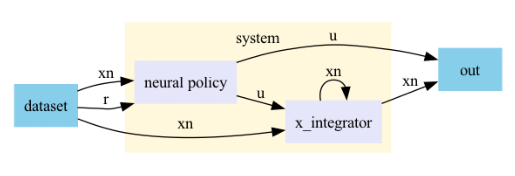

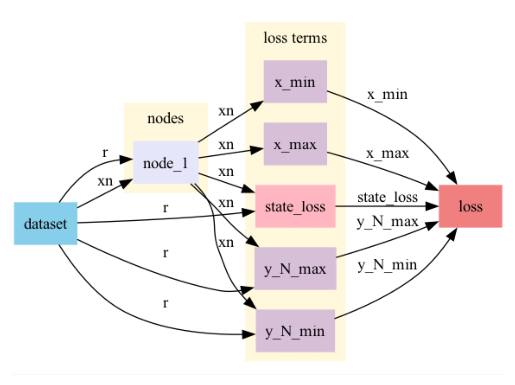

None
Number of parameters: 1249
************   training with 50 steps   ************   
epoch: 0	train_loss: 48.66643	dev_loss: 42.95743	eltime:  0.77981
epoch: 20	train_loss: 19.29114	dev_loss: 18.07568	eltime:  13.60641
epoch: 40	train_loss: 19.25561	dev_loss: 18.03574	eltime:  25.69384
epoch: 60	train_loss: 19.24742	dev_loss: 18.02513	eltime:  37.72190
epoch: 80	train_loss: 19.24413	dev_loss: 18.01945	eltime:  49.81575
epoch: 100	train_loss: 19.23268	dev_loss: 18.01359	eltime:  61.85211
epoch: 120	train_loss: 19.21011	dev_loss: 17.99272	eltime:  74.12580
epoch: 140	train_loss: 19.15264	dev_loss: 17.94607	eltime:  86.25064
epoch: 160	train_loss: 19.13806	dev_loss: 17.93156	eltime:  98.37160
epoch: 180	train_loss: 19.13465	dev_loss: 17.92791	eltime:  110.42479
epoch: 200	train_loss: 19.13270	dev_loss: 17.92563	eltime:  122.72210
epoch: 220	train_loss: 19.13120	dev_loss: 17.92401	eltime:  134.83172
epoch: 240	train_loss: 19.12995	dev_loss: 17.92271	eltime:  146.95970
epoch: 260	train_l

In [32]:
# neural net control policy with hard control action bounds
net_sindy = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=nn_config["layers"],
                    nonlin=activations['gelu'], min=umin, max=umax)
policy_neural_sindy = Node(net_sindy, ['xn', 'r'], ['u'], name='neural policy')

integ = FullStateEulerIntegrator(fx_models, ts)
integ_node = Node(integ, ['xn', 'u'], ['xn'], name="x_integrator")

neural_sindy_system = System([policy_neural_sindy, integ_node ], nsteps=nsteps)
neural_sindy_system.show()

# variables
x = variable('xn')
ref = variable('r')
# objectives
regulation_loss = nn_config['reg_coef'] * ((x == ref) ^ 2)  # target posistion
# constraints
state_lower_bound_penalty = nn_config['const_coef'] *(x > xmin)
state_upper_bound_penalty = nn_config['const_coef'] *(x < xmax)
terminal_lower_bound_penalty = nn_config['const_coef'] *(x[:, [-1], :] > ref-0.01)
terminal_upper_bound_penalty = nn_config['const_coef'] *(x[:, [-1], :] < ref+0.01)
# objectives and constraints names for nicer plot
regulation_loss.name = 'state_loss'
state_lower_bound_penalty.name = 'x_min'
state_upper_bound_penalty.name = 'x_max'
terminal_lower_bound_penalty.name = 'y_N_min'
terminal_upper_bound_penalty.name = 'y_N_max'
# list of constraints and objectives
objectives = [regulation_loss]
constraints = [
    state_lower_bound_penalty,
    state_upper_bound_penalty,
    terminal_lower_bound_penalty,
    terminal_upper_bound_penalty,
]

# data (x_k, r_k) -> parameters (xi_k) -> policy (u_k) -> dynamics (x_k+1)
components = [neural_sindy_system]
# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints)
# construct constrained optimization problem
problem = Problem(components, loss)
# plot computational graph
problem.show()

optimizer = torch.optim.AdamW(policy_neural_sindy.parameters(), lr=nn_config['lr'])
logger_NN_SINDy = BasicLogger(args=None, savedir='test', verbosity=20,
                        stdout=['dev_loss', 'train_loss'])
#  Neuromancer trainer
trainer = Trainer(
    problem,
    None,
    None,
    optimizer=optimizer,
    epochs=nn_config["epochs"],
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=nn_config["warmup"],
    patience=nn_config["patience"],
    logger=logger_NN_SINDy
)

print(f'************   training with {nsteps} steps   ************   ')
trainer.train_data, trainer.dev_data = train_loader, dev_loader
trainer.problem = problem
start_time = time.time()

# Train control policy
best_model = trainer.train()

# load best trained model
end_time = time.time()
total_time_NN_SINDy = end_time - start_time

print("Total Training time: ", total_time_NN_SINDy)

#### On White-Box Model:

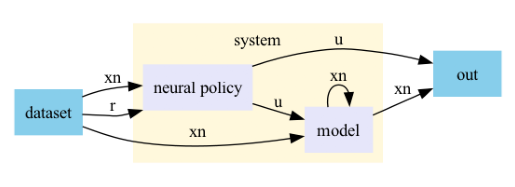

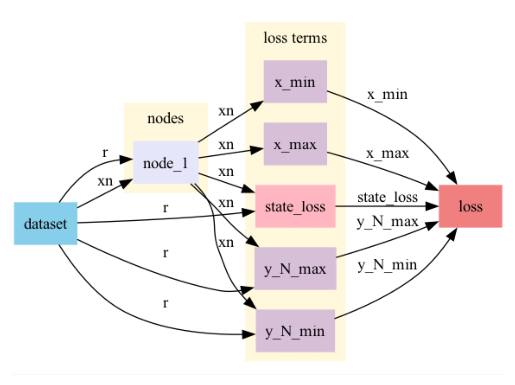

None
Number of parameters: 1250
************   training with 50 steps   ************   
epoch: 0	train_loss: 58.72321	dev_loss: 54.19553	eltime:  0.43496
epoch: 20	train_loss: 19.51819	dev_loss: 18.30163	eltime:  6.99529
epoch: 40	train_loss: 19.49127	dev_loss: 18.27573	eltime:  13.93521
epoch: 60	train_loss: 19.45878	dev_loss: 18.24677	eltime:  23.30131
epoch: 80	train_loss: 19.41601	dev_loss: 18.20836	eltime:  29.94702
epoch: 100	train_loss: 19.39367	dev_loss: 18.18744	eltime:  36.25441
epoch: 120	train_loss: 19.38943	dev_loss: 18.18258	eltime:  42.99337
epoch: 140	train_loss: 19.38718	dev_loss: 18.18015	eltime:  59.40540
epoch: 160	train_loss: 19.38536	dev_loss: 18.17828	eltime:  74.50251
epoch: 180	train_loss: 19.38386	dev_loss: 18.17680	eltime:  94.23899
epoch: 200	train_loss: 19.38203	dev_loss: 18.17494	eltime:  101.91876
epoch: 220	train_loss: 19.38031	dev_loss: 18.17331	eltime:  109.18028
epoch: 240	train_loss: 19.37875	dev_loss: 18.17203	eltime:  116.93374
epoch: 260	train_los

In [50]:
# neural net control policy with hard control action bounds
net_WB = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=nn_config["layers"],
                    nonlin=activations['gelu'], min=umin, max=umax)
policy_neural_WB = Node(net_WB, ['xn', 'r'], ['u'], name='neural policy')

neural_WB_system = System([policy_neural_WB, gt_integrator_node ], nsteps=nsteps)
neural_WB_system.show()

# variables
x = variable('xn')
ref = variable('r')
# objectives
regulation_loss = nn_config['reg_coef'] * ((x == ref) ^ 2)  # target posistion
# constraints
state_lower_bound_penalty = nn_config['const_coef'] *(x > xmin)
state_upper_bound_penalty = nn_config['const_coef'] *(x < xmax)
terminal_lower_bound_penalty = nn_config['const_coef'] *(x[:, [-1], :] > ref-0.01)
terminal_upper_bound_penalty = nn_config['const_coef'] *(x[:, [-1], :] < ref+0.01)
# objectives and constraints names for nicer plot
regulation_loss.name = 'state_loss'
state_lower_bound_penalty.name = 'x_min'
state_upper_bound_penalty.name = 'x_max'
terminal_lower_bound_penalty.name = 'y_N_min'
terminal_upper_bound_penalty.name = 'y_N_max'
# list of constraints and objectives
objectives = [regulation_loss]
constraints = [
    state_lower_bound_penalty,
    state_upper_bound_penalty,
    terminal_lower_bound_penalty,
    terminal_upper_bound_penalty,
]

# data (x_k, r_k) -> parameters (xi_k) -> policy (u_k) -> dynamics (x_k+1)
components = [neural_WB_system]
# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints)
# construct constrained optimization problem
problem = Problem(components, loss)
# plot computational graph
problem.show()

optimizer = torch.optim.AdamW(policy_neural_WB.parameters(), lr=nn_config['lr'])
logger_NN_WB = BasicLogger(args=None, savedir='test', verbosity=20,
                        stdout=['dev_loss', 'train_loss'])
#  Neuromancer trainer
trainer = Trainer(
    problem,
    None,
    None,
    optimizer=optimizer,
    epochs=nn_config["epochs"],
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=nn_config["warmup"],
    patience=nn_config["patience"],
    logger=logger_NN_WB
)

print(f'************   training with {nsteps} steps   ************   ')
trainer.train_data, trainer.dev_data = train_loader, dev_loader
trainer.problem = problem
start_time = time.time()

# Train control policy
best_model = trainer.train()

# load best trained model
end_time = time.time()
total_time_NN_WB = end_time - start_time

print("Total Training time: ", total_time_NN_WB)

In [51]:
# Output directory
save_dir = "results/tests/neural"
os.makedirs(save_dir, exist_ok=True)

# Save the state_dict of each policy
torch.save(policy_neural_sindy.state_dict(), os.path.join(save_dir, "policy_neural_sindy.pth"))
torch.save(policy_neural_WB.state_dict(), os.path.join(save_dir, "policy_neural_WB.pth"))

# Save the nn_config as JSON
with open(os.path.join(save_dir, "nn_config.json"), "w") as f:
    json.dump(nn_config, f, indent=4)